# 🏎️ F1 Race Simulator - Validazione Modelli

**Modello**: Predice P(pit entro 3 giri) - NON il giro esatto del pit!

**Valutazione corretta**:
- Un giro con P > threshold è **True Positive** se c'è un pit nei prossimi 1-3 giri
- Un giro con P > threshold è **False Positive** solo se NON c'è pit nei prossimi 3 giri
- **Early Warning**: quanti giri prima del pit il modello inizia a segnalare

In [21]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model

plt.style.use('seaborn-v0_8-whitegrid')
COMPOUND_COLORS = {'SOFT': '#FF3333', 'MEDIUM': '#FFD700', 'HARD': '#E8E8E8',
                   'INTERMEDIATE': '#39FF14', 'WET': '#00BFFF'}
PREDICTION_WINDOW = 3  # Il modello predice pit entro N giri

In [22]:
# FastF1: libreria open-source per dati F1 (telemetria, tempi, meteo)
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

In [23]:
# Carica configurazione e modelli
with open('modelConfig.json', 'r') as f:
    config = json.load(f)

model_pit = load_model('f1_pit_model.keras')
model_comp = load_model('f1_compound_model.keras')
scaler_pit = joblib.load('f1_pit_scaler.pkl')
scaler_comp = joblib.load('f1_comp_scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')

SEQ_LEN = config['sequence_length']
FEATURES_PIT = config['features_pit']
FEATURES_COMP = config['features_compound']
PIT_THRESHOLD = config['pit_threshold']+0.15

print(f"✓ Modelli caricati | Seq={SEQ_LEN} | Threshold={PIT_THRESHOLD:.3f}")

✓ Modelli caricati | Seq=10 | Threshold=0.796


In [24]:
df_f1 = pd.read_pickle('f1_dataset_featured.pkl')
print(f"Dataset: {len(df_f1):,} righe | Anni: {df_f1['Year'].min()}-{df_f1['Year'].max()}")

Dataset: 86,757 righe | Anni: 2022-2025


In [25]:
# ========== CONFIGURA QUI ==========
SELECTED_YEAR = 2025
SELECTED_ROUND = 14
TOP_N_DRIVERS = 'HAM'
# ===================================

race_data = df_f1[(df_f1['Year'] == SELECTED_YEAR) & (df_f1['Round'] == SELECTED_ROUND)].copy()
race_name = race_data['RaceName'].iloc[0] if len(race_data) > 0 else "N/A"
print(f"✓ {race_name} | {race_data['Driver'].nunique()} piloti | {int(race_data['LapNumber'].max())} giri")

✓ Hungarian Grand Prix | 20 piloti | 70 giri


## 🔮 Simulatore con Valutazione Corretta

In [26]:
class RaceSimulator:
    """Simula predizioni giro per giro con valutazione a finestra."""

    def __init__(self, model_pit, model_comp, scaler_pit, scaler_comp,
                 label_encoder, features_pit, features_comp, seq_len, threshold, window=3):
        self.model_pit = model_pit
        self.model_comp = model_comp
        self.scaler_pit = scaler_pit
        self.scaler_comp = scaler_comp
        self.label_encoder = label_encoder
        self.features_pit = features_pit
        self.features_comp = features_comp
        self.seq_len = seq_len
        self.threshold = threshold
        self.window = window

    def _prepare_sequence(self, history_df, features, scaler):
        data = history_df[features].values.astype(np.float32)
        data = scaler.transform(data)
        if len(data) < self.seq_len:
            pad = np.zeros((self.seq_len - len(data), len(features)), dtype=np.float32)
            data = np.vstack([pad, data])
        else:
            data = data[-self.seq_len:]
        return data.reshape(1, self.seq_len, len(features))

    def simulate_driver(self, full_race_df, driver):
        driver_df = full_race_df[full_race_df['Driver'] == driver].sort_values('LapNumber').reset_index(drop=True)
        if len(driver_df) < 2:
            return None

        # Identifica giri di pit (cambio stint)
        pit_laps = set()
        for i in range(1, len(driver_df)):
            if driver_df.iloc[i]['Stint'] != driver_df.iloc[i-1]['Stint']:
                pit_laps.add(int(driver_df.iloc[i]['LapNumber']))

        results = []
        for lap_idx in range(1, len(driver_df)):
            history = driver_df.iloc[:lap_idx].copy()
            current = driver_df.iloc[lap_idx]
            current_lap = int(current['LapNumber'])

            # Predizione
            seq_pit = self._prepare_sequence(history, self.features_pit, self.scaler_pit)
            seq_comp = self._prepare_sequence(history, self.features_comp, self.scaler_comp)
            pit_prob = float(self.model_pit.predict(seq_pit, verbose=0)[0, 0])
            comp_probs = self.model_comp.predict(seq_comp, verbose=0)[0]
            comp_pred = self.label_encoder.classes_[comp_probs.argmax()]

            # Ground truth: c'è un pit nei prossimi 'window' giri?
            pit_in_window = any(current_lap + i in pit_laps for i in range(1, self.window + 1))
            pit_this_lap = current_lap in pit_laps

            # Compound reale (solo se pit effettivo)
            if pit_this_lap:
                next_stint_data = driver_df[driver_df['Stint'] == current['Stint']]
                comp_actual = next_stint_data['Compound'].iloc[0] if len(next_stint_data) > 0 else None
            else:
                comp_actual = None

            results.append({
                'Lap': current_lap,
                'Stint': int(history.iloc[-1]['Stint']),
                'Compound': history.iloc[-1]['Compound'],
                'TyreAge': int(history.iloc[-1]['TyreLife']),
                'PitProb': pit_prob,
                'PitPred': int(pit_prob >= self.threshold),
                'PitInWindow': int(pit_in_window),  # Ground truth per finestra
                'PitThisLap': int(pit_this_lap),    # Pit effettivo questo giro
                'CompPred': comp_pred,
                'CompActual': comp_actual
            })

        return pd.DataFrame(results)

In [28]:
simulator = RaceSimulator(
    model_pit, model_comp, scaler_pit, scaler_comp, label_encoder,
    FEATURES_PIT, FEATURES_COMP, SEQ_LEN, PIT_THRESHOLD, PREDICTION_WINDOW
)

final_positions = race_data.groupby('Driver')['Position'].last().sort_values()
# Corrected: Assume TOP_N_DRIVERS specifies a single driver to simulate
top_drivers = [TOP_N_DRIVERS]

all_results = {}
for driver in top_drivers:
    result = simulator.simulate_driver(race_data, driver)
    if result is not None:
        all_results[driver] = result
        pits = result['PitThisLap'].sum()
        print(f"  ✓ {driver}: {len(result)} giri, {pits} pit")

  ✓ HAM: 65 giri, 1 pit


## 📊 Metriche Corrette (Finestra 3 Giri)

In [29]:
def compute_window_metrics(results_dict):
    """
    Metriche con logica ALERT: giri consecutivi sopra soglia = 1 solo alert.

    PRIMA: 4 giri consecutivi sopra soglia = 4 predizioni = 4 FP se no pit
    ORA:   4 giri consecutivi sopra soglia = 1 ALERT = 1 FP se no pit
    """
    metrics = []

    for driver, df in results_dict.items():
        df = df.copy()

        # Identifica ALERT (sequenze consecutive di PitPred=1)
        df['PrevPred'] = df['PitPred'].shift(1).fillna(0)
        df['AlertStart'] = ((df['PitPred'] == 1) & (df['PrevPred'] == 0)).astype(int)
        df['AlertID'] = df['AlertStart'].cumsum()
        df.loc[df['PitPred'] == 0, 'AlertID'] = 0

        alerts = df[df['AlertStart'] == 1].copy()
        pit_laps = set(df[df['PitThisLap'] == 1]['Lap'].values)

        tp = 0
        fp = 0
        predicted_pits = set()
        early_warnings = []

        for _, alert in alerts.iterrows():
            alert_lap = int(alert['Lap'])
            alert_id = alert['AlertID']

            # Trova fine dell'alert (tutti giri consecutivi)
            alert_all = df[df['AlertID'] == alert_id]
            alert_end = int(alert_all['Lap'].max())

            # Cerca pit nella finestra: da inizio alert a fine + window
            window = PREDICTION_WINDOW
            search_end = alert_end + window
            pits_in_range = [p for p in pit_laps if alert_lap <= p <= search_end and p not in predicted_pits]

            if pits_in_range:
                # TP: alert ha catturato un pit
                pit = pits_in_range[0]
                tp += 1
                predicted_pits.add(pit)
                early_warnings.append(pit - alert_lap)
            else:
                # FP: alert senza pit nella finestra
                fp += 1

        # FN: pit non catturati
        fn = len(pit_laps - predicted_pits)

        # TN: giri senza alert e senza pit in finestra
        no_alert = df[df['PitPred'] == 0]
        tn = len(no_alert[no_alert['PitInWindow'] == 0])

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

        avg_early = np.mean(early_warnings) if early_warnings else 0

        # Compound accuracy
        actual_pits = df[df['PitThisLap'] == 1]
        comp_acc = (actual_pits['CompPred'] == actual_pits['CompActual']).mean() if len(actual_pits) > 0 else None

        metrics.append({
            'Driver': driver,
            'Pits': len(pit_laps),
            'Alerts': len(alerts),
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'EarlyWarn': avg_early,
            'CompAcc': comp_acc
        })

    return pd.DataFrame(metrics)

metrics_df = compute_window_metrics(all_results)

print(f"\n📊 METRICHE CON LOGICA ALERT (giri consecutivi = 1 alert)")
print("=" * 90)
print(f"{'Driver':<8} {'Pits':<6} {'Alerts':<8} {'TP':<4} {'FP':<4} {'FN':<4} {'Prec':<8} {'Recall':<8} {'F1':<8} {'Early':<6}")
print("-" * 90)
for _, row in metrics_df.iterrows():
    print(f"{row['Driver']:<8} {int(row['Pits']):<6} {int(row['Alerts']):<8} "
          f"{int(row['TP']):<4} {int(row['FP']):<4} {int(row['FN']):<4} "
          f"{row['Precision']:.0%}      {row['Recall']:.0%}      {row['F1']:.0%}      {row['EarlyWarn']:.1f}g")

print("\n" + "-" * 50)
print(f"TOTALE | Precision: {metrics_df['Precision'].mean():.1%} | Recall: {metrics_df['Recall'].mean():.1%} | F1: {metrics_df['F1'].mean():.1%}")
print(f"       | Early Warning: {metrics_df['EarlyWarn'].mean():.1f} giri | Compound Acc: {metrics_df['CompAcc'].mean():.1%}")


📊 METRICHE CON LOGICA ALERT (giri consecutivi = 1 alert)
Driver   Pits   Alerts   TP   FP   FN   Prec     Recall   F1       Early 
------------------------------------------------------------------------------------------
HAM      1      2        1    1    0    50%      100%      67%      4.0g

--------------------------------------------------
TOTALE | Precision: 50.0% | Recall: 100.0% | F1: 66.7%
       | Early Warning: 4.0 giri | Compound Acc: 100.0%


## 📉 Visualizzazioni

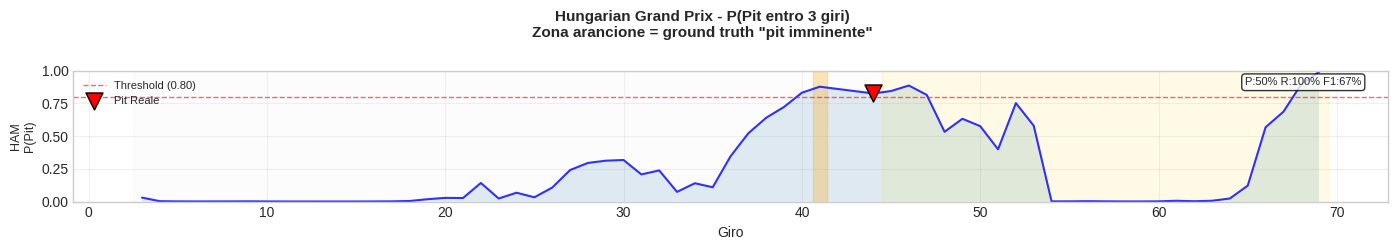

In [30]:
def plot_simulation_v2(results_dict, race_name, threshold, window):
    """Grafico con evidenza della finestra di predizione."""
    n = len(results_dict)
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n), sharex=True)
    if n == 1: axes = [axes]

    for idx, (driver, df) in enumerate(results_dict.items()):
        ax = axes[idx]

        # Probabilità pit
        ax.plot(df['Lap'], df['PitProb'], 'b-', lw=1.5, alpha=0.8)
        ax.axhline(threshold, color='red', ls='--', lw=1, alpha=0.6, label=f'Threshold ({threshold:.2f})')
        ax.fill_between(df['Lap'], 0, df['PitProb'], alpha=0.15)

        # Evidenzia zone "pit in window" (ground truth)
        in_window = df[df['PitInWindow'] == 1]
        for _, row in in_window.iterrows():
            ax.axvspan(row['Lap'] - 0.4, row['Lap'] + 0.4, alpha=0.3, color='orange')

        # Pit reali
        pits = df[df['PitThisLap'] == 1]
        ax.scatter(pits['Lap'], pits['PitProb'], c='red', s=150, zorder=5,
                   marker='v', edgecolors='black', label='Pit Reale')

        # Sfondo compound
        for stint in df['Stint'].unique():
            stint_df = df[df['Stint'] == stint]
            comp = stint_df['Compound'].iloc[0]
            ax.axvspan(stint_df['Lap'].min() - 0.5, stint_df['Lap'].max() + 0.5,
                       alpha=0.1, color=COMPOUND_COLORS.get(comp, 'gray'))

        ax.set_ylabel(f'{driver}\nP(Pit)', fontsize=9)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)

        # Metriche pilota
        m = metrics_df[metrics_df['Driver'] == driver].iloc[0]
        ax.text(0.98, 0.95, f"P:{m['Precision']:.0%} R:{m['Recall']:.0%} F1:{m['F1']:.0%}",
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        if idx == 0:
            ax.legend(loc='upper left', fontsize=8)

    axes[-1].set_xlabel('Giro', fontsize=10)
    fig.suptitle(f'{race_name} - P(Pit entro {window} giri)\nZona arancione = ground truth "pit imminente"',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    return fig

fig1 = plot_simulation_v2(all_results, race_name, PIT_THRESHOLD, PREDICTION_WINDOW)
plt.savefig(f'sim_{SELECTED_YEAR}_R{SELECTED_ROUND}.png', dpi=150, bbox_inches='tight')
plt.show()

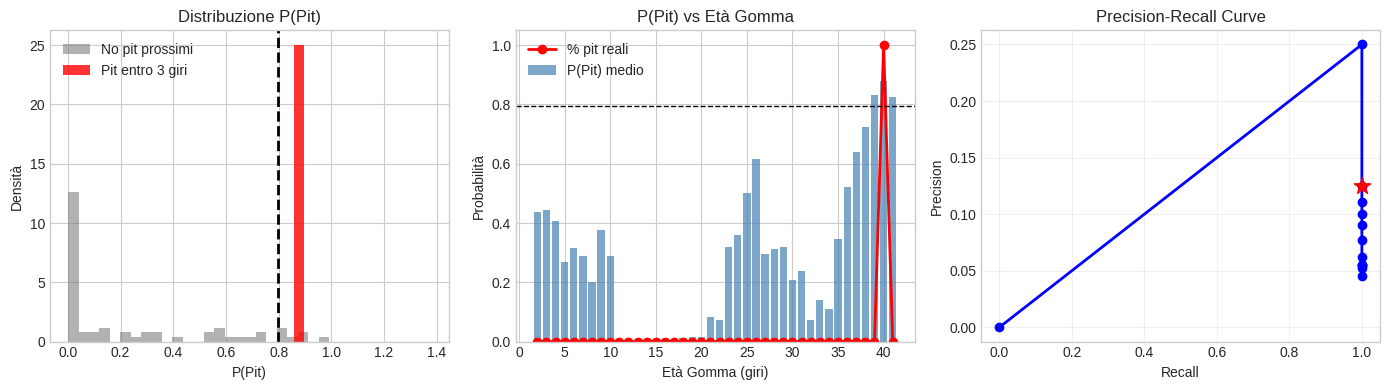

In [31]:
def plot_analysis(results_dict, threshold):
    """Analisi distribuzione probabilità."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    all_data = pd.concat(results_dict.values())

    # 1. Distribuzione P(Pit) per classe
    ax1 = axes[0]
    pit_window = all_data[all_data['PitInWindow'] == 1]['PitProb']
    no_pit = all_data[all_data['PitInWindow'] == 0]['PitProb']
    ax1.hist(no_pit, bins=25, alpha=0.6, label='No pit prossimi', color='gray', density=True)
    ax1.hist(pit_window, bins=25, alpha=0.8, label='Pit entro 3 giri', color='red', density=True)
    ax1.axvline(threshold, color='black', ls='--', lw=2)
    ax1.set_xlabel('P(Pit)')
    ax1.set_ylabel('Densità')
    ax1.set_title('Distribuzione P(Pit)')
    ax1.legend()

    # 2. P(Pit) vs TyreAge
    ax2 = axes[1]
    by_age = all_data.groupby('TyreAge').agg({'PitProb': 'mean', 'PitInWindow': 'mean'}).reset_index()
    ax2.bar(by_age['TyreAge'], by_age['PitProb'], alpha=0.7, label='P(Pit) medio', color='steelblue')
    ax2.plot(by_age['TyreAge'], by_age['PitInWindow'], 'ro-', lw=2, label='% pit reali')
    ax2.axhline(threshold, color='black', ls='--', lw=1)
    ax2.set_xlabel('Età Gomma (giri)')
    ax2.set_ylabel('Probabilità')
    ax2.set_title('P(Pit) vs Età Gomma')
    ax2.legend()

    # 3. ROC-like: Early warning vs Threshold
    ax3 = axes[2]
    thresholds = np.arange(0.3, 0.9, 0.05)
    recalls, precisions = [], []
    for t in thresholds:
        pred = (all_data['PitProb'] >= t).astype(int)
        tp = ((pred == 1) & (all_data['PitInWindow'] == 1)).sum()
        fp = ((pred == 1) & (all_data['PitInWindow'] == 0)).sum()
        fn = ((pred == 0) & (all_data['PitInWindow'] == 1)).sum()
        recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)

    ax3.plot(recalls, precisions, 'b-o', lw=2)
    # Evidenzia threshold attuale
    idx = np.argmin(np.abs(thresholds - threshold))
    ax3.scatter([recalls[idx]], [precisions[idx]], c='red', s=150, zorder=5, marker='*')
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title('Precision-Recall Curve')
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

fig2 = plot_analysis(all_results, PIT_THRESHOLD)
plt.show()

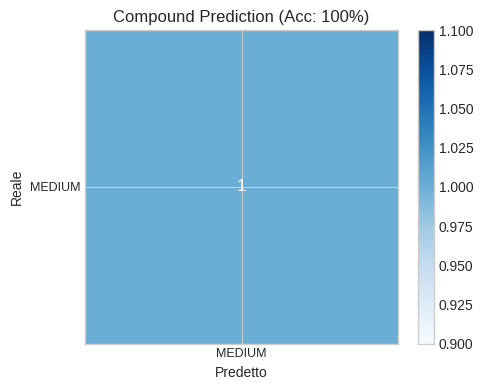

In [32]:
def plot_compound_matrix(results_dict):
    """Matrice confusione compound."""
    actual, pred = [], []
    for df in results_dict.values():
        pits = df[df['PitThisLap'] == 1].dropna(subset=['CompActual'])
        actual.extend(pits['CompActual'].tolist())
        pred.extend(pits['CompPred'].tolist())

    if not actual:
        print("Nessun pit con compound noto.")
        return None

    labels = sorted(set(actual + pred))
    conf = pd.crosstab(pd.Series(actual, name='Reale'), pd.Series(pred, name='Predetto'))
    conf = conf.reindex(index=labels, columns=labels, fill_value=0)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(conf.values, cmap='Blues')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predetto')
    ax.set_ylabel('Reale')

    for i in range(len(labels)):
        for j in range(len(labels)):
            val = conf.values[i, j]
            ax.text(j, i, str(val), ha='center', va='center',
                    color='white' if val > conf.values.max()/2 else 'black', fontsize=12)

    acc = (np.array(actual) == np.array(pred)).mean()
    ax.set_title(f'Compound Prediction (Acc: {acc:.0%})')
    plt.colorbar(im)
    plt.tight_layout()
    return fig

fig3 = plot_compound_matrix(all_results)
plt.show()

## 🔍 Analisi Dettagliata

In [35]:
def analyze_driver_alerts(results_dict, driver, window=3):
    """Analisi dettagliata con logica ALERT."""
    if driver not in results_dict:
        print(f"Pilota {driver} non trovato.")
        return

    df = results_dict[driver].copy()

    # Calcola alert sessions
    df['PrevPred'] = df['PitPred'].shift(1).fillna(0)
    df['AlertStart'] = ((df['PitPred'] == 1) & (df['PrevPred'] == 0)).astype(int)
    df['AlertID'] = df['AlertStart'].cumsum()
    df.loc[df['PitPred'] == 0, 'AlertID'] = 0

    pit_laps = sorted(df[df['PitThisLap'] == 1]['Lap'].values)
    alerts = df[df['AlertStart'] == 1]

    print(f"\n🏎️ {driver} - Analisi Alert")
    print("=" * 60)
    print(f"Pit reali: giri {pit_laps}")
    print(f"Alert totali: {len(alerts)}")

    predicted_pits = set()

    for _, alert in alerts.iterrows():
        alert_lap = int(alert['Lap'])
        alert_id = alert['AlertID']
        alert_all = df[df['AlertID'] == alert_id]
        alert_end = int(alert_all['Lap'].max())
        duration = alert_end - alert_lap + 1
        p_max = alert_all['PitProb'].max()

        # Cerca pit in finestra
        search_end = alert_end + window
        pits_found = [p for p in pit_laps if alert_lap <= p <= search_end and p not in predicted_pits]

        if pits_found:
            pit = pits_found[0]
            predicted_pits.add(pit)
            early = pit - alert_lap
            pit_row = df[df['Lap'] == pit].iloc[0]
            comp_match = "✓" if pit_row['CompPred'] == pit_row['CompActual'] else "✗"
            print(f"\n  ✓ Alert giri {alert_lap}-{alert_end} (P_max={p_max:.2f})")
            print(f"    → TP: Pit giro {pit} | Early: {early}g | Compound: {pit_row['CompPred']} vs {pit_row['CompActual']} {comp_match}")
        else:
            print(f"\n  ✗ Alert giri {alert_lap}-{alert_end} (P_max={p_max:.2f})")
            print(f"    → FP: Nessun pit nella finestra")

    # Pit mancati
    missed = set(pit_laps) - predicted_pits
    if missed:
        print(f"\n  ⚠️ FN: Pit mancati ai giri {sorted(missed)}")

for driver in list(all_results.keys())[:5]:
    analyze_driver_alerts(all_results, driver, PREDICTION_WINDOW)


🏎️ HAM - Analisi Alert
Pit reali: giri [np.int64(44)]
Alert totali: 2

  ✓ Alert giri 40-47 (P_max=0.89)
    → TP: Pit giro 44 | Early: 4g | Compound: MEDIUM vs MEDIUM ✓

  ✗ Alert giri 68-69 (P_max=0.99)
    → FP: Nessun pit nella finestra


## 📋 Riepilogo

In [34]:
# Aggregati
tot_tp = metrics_df['TP'].sum()
tot_fp = metrics_df['FP'].sum()
tot_fn = metrics_df['FN'].sum()
tot_alerts = metrics_df['Alerts'].sum()
tot_pits = metrics_df['Pits'].sum()

overall_p = tot_tp / (tot_tp + tot_fp) if (tot_tp + tot_fp) > 0 else 0
overall_r = tot_tp / (tot_tp + tot_fn) if (tot_tp + tot_fn) > 0 else 0
overall_f1 = 2 * overall_p * overall_r / (overall_p + overall_r) if (overall_p + overall_r) > 0 else 0

print("\n" + "=" * 70)
print(f"📊 RIEPILOGO - {race_name}")
print(f"   Logica: ALERT (giri consecutivi = 1 alert)")
print(f"   Threshold: {PIT_THRESHOLD:.3f} | Finestra: {PREDICTION_WINDOW} giri")
print("=" * 70)

print(f"\n🎯 PIT PREDICTION:")
print(f"   Alert totali: {int(tot_alerts)} | Pit reali: {int(tot_pits)}")
print(f"   TP: {int(tot_tp)} | FP: {int(tot_fp)} | FN: {int(tot_fn)}")
print(f"   Precision: {overall_p:.1%} | Recall: {overall_r:.1%} | F1: {overall_f1:.1%}")
print(f"   Early Warning medio: {metrics_df['EarlyWarn'].mean():.1f} giri")

print(f"\n🎨 COMPOUND PREDICTION:")
print(f"   Accuracy: {metrics_df['CompAcc'].mean():.1%}")

print("\n" + "=" * 70)


📊 RIEPILOGO - Hungarian Grand Prix
   Logica: ALERT (giri consecutivi = 1 alert)
   Threshold: 0.796 | Finestra: 3 giri

🎯 PIT PREDICTION:
   Alert totali: 2 | Pit reali: 1
   TP: 1 | FP: 1 | FN: 0
   Precision: 50.0% | Recall: 100.0% | F1: 66.7%
   Early Warning medio: 4.0 giri

🎨 COMPOUND PREDICTION:
   Accuracy: 100.0%

